Aluno(a): ALICE SOPHIA LIMA VIEIRA
Matéria: Ciência dos Dados 2026_01
Professor: LUIS CUEVAS RODRIGUEZ

### Descrição do Dataset:

- Nome do Dataset: Prouni - Relatório de Dados Abertos 2020

- Link Original: https://dados.gov.br/dados/conjuntos-dados/mec-prouni

- Órgão Responsável: Ministério da Educação (MEC)

- Tema e Finalidade:

O presente conjunto de dados detalha a concessão de bolsas do Prouni (Programa Universidade para Todos) referentes ao ano de 2020. O foco principal deste dataset é promover a auditabilidade e a transparência pública, permitindo o acompanhamento social sobre o destino dos recursos e das isenções fiscais concedidas às instituições privadas de ensino superior em contrapartida às bolsas.

A análise destes dados é fundamental para que pesquisadores e analistas consigam traçar o perfil socioeconômico dos beneficiários, segmentando-os por raça, sexo e idade. Além disso, os dados permitem o mapeamento da abrangência geográfica do programa, identificando as regiões, estados e municípios que concentram o maior volume de auxílios.

No âmbito acadêmico, o dataset possibilita uma análise detalhada da oferta de cursos, revelando quais áreas do conhecimento, como Pedagogia, Direito ou Engenharia, possuem maior adesão de bolsistas. Por fim, o relatório permite a comparação entre as modalidades de ensino, evidenciando a proporção de bolsas destinadas a cursos presenciais em relação ao Ensino a Distância (EAD), refletindo as tendências educacionais do período.

### Significado das Variáveis
Abaixo estão as descrições das principais colunas encontradas no arquivo do Prouni 2020:

**ANO_CONCESSAO_BOLSA:** Refere-se ao ano em que o benefício foi concedido ao aluno (neste caso, 2020).

**CODIGO_EMEC_IES_BOLSA:** Código de identificação da Instituição de Ensino Superior no sistema do Ministério da Educação.

**NOME_IES_BOLSA:** Nome da faculdade ou universidade onde a bolsa está sendo utilizada (Ex: UNIP, Estácio, São Judas).

**TIPO_BOLSA:** Define o percentual do benefício, podendo ser Integral (100% da mensalidade) ou Parcial (50%).

**MODALIDADE_ENSINO_BOLSA:** Indica o formato das aulas, sendo Presencial ou EAD (Educação a Distância).

**NOME_CURSO_BOLSA:** O curso de graduação para o qual a bolsa foi destinada (Ex: Pedagogia, Direito, Farmácia).

**NOME_TURNO_CURSO_BOLSA:** O período das aulas, como Matutino, Noturno ou "Curso a Distância".

**SEXO_BENEFICIARIO:** Sexo biológico do aluno (F para Feminino e M para Masculino).

**RACA_BENEFICIARIO:** Perfil étnico-racial autodeclarado pelo aluno (Ex: Parda, Branca, Preta).

**BENEFICIARIO_DEFICIENTE_FISICO:** Campo binário (S/N) indicando se o bolsista é uma Pessoa com Deficiência (PCD).

**REGIAO_BENEFICIARIO / UF_BENEFICIARIO:** Localização geográfica (Região e Estado) de residência ou origem do aluno beneficiado.

In [1]:
# Importando bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [3]:
# Carregar os dados
df = pd.read_csv(r"C:\Users\alice\OneDrive\Documentos\Data Science\DATASET\ProuniRelatorioDadosAbertos2020.csv", sep=';', encoding='latin1')

# Exibir as primeiras 5 linhas
df.head()

,ANO_CONCESSAO_BOLSA,CODIGO_EMEC_IES_BOLSA,NOME_IES_BOLSA,MUNICIPIO,CAMPUS,TIPO_BOLSA,MODALIDADE_ENSINO_BOLSA,NOME_CURSO_BOLSA,NOME_TURNO_CURSO_BOLSA,CPF_BENEFICIARIO,SEXO_BENEFICIARIO,RACA_BENEFICIARIO,DATA_NASCIMENTO,BENEFICIARIO_DEFICIENTE_FISICO,REGIAO_BENEFICIARIO,UF_BENEFICIARIO,MUNICIPIO_BENEFICIARIO
0,2020,322,UNIVERSIDADE PAULISTA,IPATINGA,IPATINGA,INTEGRAL,EAD,PEDAGOGIA,CURSO A DISTÂNCIA,991.XXX.XXX-91,F,Parda,11/08/1973,N,SUDESTE,MG,GOVERNADOR VALADARES
1,2020,163,UNIVERSIDADE ESTÁCIO DE SÁ,FORTALEZA,EAD VIA CORPVS - CE,INTEGRAL,EAD,MARKETING,CURSO A DISTÂNCIA,067.XXX.XXX-01,M,Parda,13/05/1987,N,NORDESTE,CE,FORTALEZA
2,2020,17670,FACULDADE DE QUIXERAMOBIM,QUIXERAMOBIM,FACULDADE DE QUIXERAMOBIM - UNIQ,INTEGRAL,PRESENCIAL,FARMÁCIA,NOTURNO,623.XXX.XXX-27,M,Parda,23/07/2001,N,NORDESTE,CE,MOMBACA
3,2020,203,UNIVERSIDADE SÃO JUDAS TADEU,SAO PAULO,PAULISTA,PARCIAL,PRESENCIAL,DIREITO,MATUTINO,089.XXX.XXX-40,F,Branca,04/04/2003,N,NORDESTE,BA,IBITITA
4,2020,203,UNIVERSIDADE SÃO JUDAS TADEU,SAO PAULO,PAULISTA,INTEGRAL,PRESENCIAL,DIREITO,MATUTINO,173.XXX.XXX-09,F,Branca,07/12/1977,N,SUDESTE,SP,SAO PAULO


In [6]:
# Cálculo de Tipos de Dados e Valores Ausentes 
print("Tipos de Dados:") 
print(df.dtypes) 
print("\nValores Ausentes:") 
print(df.isnull().sum()) 

# Criando a coluna de Idade (Ano de referência: 2020) 
df['DATA_NASCIMENTO'] = pd.to_datetime(df['DATA_NASCIMENTO'], errors='coerce', dayfirst=True) 
df['IDADE'] = 2020 - df['DATA_NASCIMENTO'].dt.year

# Removendo possíveis dados inconsistentes (idades irreais) 
df = df[(df['IDADE'] > 0) & (df['IDADE'] < 100)]

Tipos de Dados:
ANO_CONCESSAO_BOLSA                        int64
CODIGO_EMEC_IES_BOLSA                      int64
NOME_IES_BOLSA                            object
MUNICIPIO                                 object
CAMPUS                                    object
TIPO_BOLSA                                object
MODALIDADE_ENSINO_BOLSA                   object
NOME_CURSO_BOLSA                          object
NOME_TURNO_CURSO_BOLSA                    object
CPF_BENEFICIARIO                          object
SEXO_BENEFICIARIO                         object
RACA_BENEFICIARIO                         object
DATA_NASCIMENTO                   datetime64[ns]
BENEFICIARIO_DEFICIENTE_FISICO            object
REGIAO_BENEFICIARIO                       object
UF_BENEFICIARIO                           object
MUNICIPIO_BENEFICIARIO                    object
IDADE                                      int32
dtype: object

Valores Ausentes:
ANO_CONCESSAO_BOLSA                0
CODIGO_EMEC_IES_BOLSA           

In [10]:
# count (quantidade de registros), mean (média), std (desvio padrão), min (menor valor), 
# 25% (primeiro quartil), 50% (mediana), 75% (terceiro quartil),max (maior valor)

print("Resumo Estatístico:")
print(df['IDADE'].describe())

moda = df['IDADE'].mode()[0]
variancia = df['IDADE'].var()

q1 = df['IDADE'].quantile(0.25)
q3 = df['IDADE'].quantile(0.75)
iqr = q3 - q1

print("\nEstatísticas adicionais:")
print(f"Moda: {moda}")
print(f"Variância: {variancia:.2f}")
print(f"Intervalo Interquartil (IQR): {iqr:.2f}")

Resumo Estatístico:
count    166824.000000
mean         23.050436
std           6.600508
min           1.000000
25%          19.000000
50%          20.000000
75%          25.000000
max          91.000000
Name: IDADE, dtype: float64

Estatísticas adicionais:
Moda: 19
Variância: 43.57
Intervalo Interquartil (IQR): 6.00


#### Gráficos: Histograma, Boxplot e Dispersão


Gerando visualizações com base na coluna IDADE...



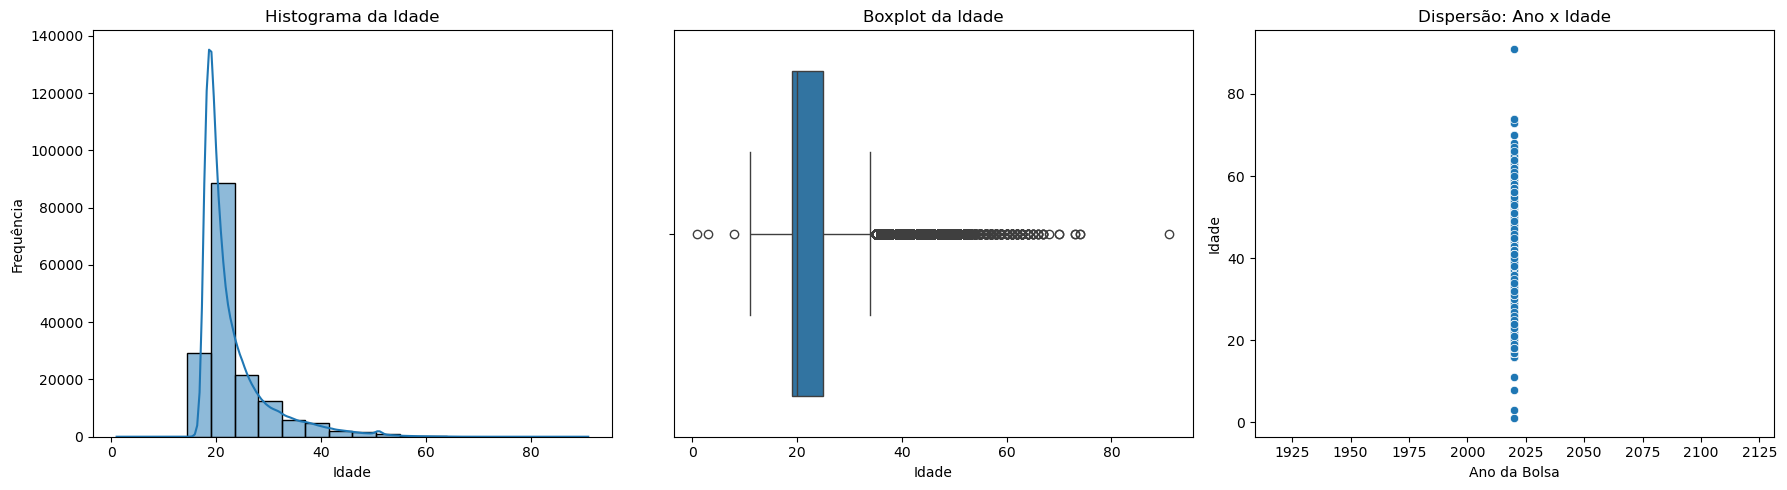

In [12]:
print("\nGerando visualizações com base na coluna IDADE...\n")

fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Histograma
sns.histplot(df['IDADE'], bins=20, kde=True, ax=axes[0])
axes[0].set_title("Histograma da Idade")
axes[0].set_xlabel("Idade")
axes[0].set_ylabel("Frequência")

# Boxplot
sns.boxplot(x=df['IDADE'], ax=axes[1])
axes[1].set_title("Boxplot da Idade")
axes[1].set_xlabel("Idade")

# Dispersão
sns.scatterplot(x=df['ANO_CONCESSAO_BOLSA'], y=df['IDADE'], ax=axes[2])
axes[2].set_title("Dispersão: Ano x Idade")
axes[2].set_xlabel("Ano da Bolsa")
axes[2].set_ylabel("Idade")

plt.tight_layout()
plt.show()

#### Resultados: Que padrões ou irregularidades você observou?

1. Histograma

A análise do histograma da variável idade mostra que existe uma grande concentração de beneficiários na faixa etária entre aproximadamente 18 e 25 anos, indicando que a maioria das bolsas é concedida a pessoas que estão na idade típica de ingresso no ensino superior. Observa-se também um pico próximo aos 20 anos, o que indica que essa é uma das idades mais frequentes no conjunto de dados, resultado que está de acordo com as estatísticas calculadas anteriormente, em que a mediana da idade é 20 anos.

Além disso, o histograma apresenta uma assimetria positiva, ou seja, a distribuição possui uma cauda mais longa para a direita. Isso significa que existem alguns beneficiários com idades mais elevadas, como 30, 40 ou até mais anos, porém em quantidade bem menor quando comparados aos beneficiários mais jovens. Esse comportamento é esperado em dados relacionados ao ensino superior, onde a maior parte dos estudantes ingressa logo após concluir o ensino médio.

Também é possível observar a presença de alguns valores extremos, com idades mais altas, chegando próximas de 90 anos. Esses casos são pouco frequentes e podem representar pessoas que ingressaram no ensino superior em idade mais avançada ou possíveis outliers no conjunto de dados. De forma geral, o histograma indica que o perfil predominante dos beneficiários é composto por jovens adultos, com forte concentração nas idades iniciais da vida acadêmica.

2. Boxplot
   
O boxplot da idade permite visualizar a distribuição dos dados de forma resumida, destacando a mediana, os quartis e possíveis valores extremos (outliers). No gráfico, a caixa central representa o intervalo entre o primeiro quartil (Q1) e o terceiro quartil (Q3), que contém 50% das observações. A linha dentro da caixa indica a mediana da idade, que está próxima de 20 anos, mostrando que metade dos beneficiários possui idade abaixo desse valor e metade acima.

Observa-se que a maior parte das idades está concentrada aproximadamente entre 19 e 25 anos, faixa correspondente ao intervalo interquartil. Esse resultado reforça a análise feita anteriormente no histograma, indicando que a maioria dos beneficiários é composta por jovens adultos em idade típica de ingresso no ensino superior.

Além disso, o boxplot mostra a presença de diversos pontos fora da região dos “bigodes”, que representam outliers. Esses pontos correspondem a idades mais altas, como 40, 50 anos ou mais, chegando até valores próximos de 90 anos. Esses casos são menos frequentes no conjunto de dados e podem representar beneficiários que ingressaram no ensino superior em idade mais avançada.

De forma geral, o boxplot confirma que a distribuição das idades é assimétrica à direita, com maior concentração em idades mais baixas e uma cauda composta por valores mais altos. Isso indica que, embora a maioria dos beneficiários seja jovem, existe uma pequena parcela de pessoas com idade significativamente maior participando do programa de bolsas.

3. Dispersão

O gráfico de dispersão entre o ano da bolsa e a idade permite observar a relação entre essas duas variáveis, representando cada beneficiário por meio de um ponto no gráfico. No eixo horizontal está o ano da bolsa, enquanto no eixo vertical está a idade dos beneficiários.

Observa-se que a maior parte dos pontos está concentrada em um único ano, formando praticamente uma coluna vertical de pontos. Isso indica que os registros do conjunto de dados estão majoritariamente associados ao mesmo ano de concessão da bolsa, não havendo grande variação temporal entre os dados analisados.

Em relação à idade, percebe-se uma ampla dispersão dos valores ao longo do eixo vertical. As idades variam desde valores muito baixos até idades mais elevadas, chegando próximas de 90 anos. No entanto, a maior concentração de pontos encontra-se aproximadamente entre 18 e 30 anos, o que reforça a ideia de que a maioria dos beneficiários é composta por jovens adultos em idade típica de ingresso no ensino superior.

De modo geral, o gráfico não apresenta uma tendência clara de relação entre o ano da bolsa e a idade, já que praticamente todos os dados estão concentrados em um mesmo período. Assim, o principal aspecto observado é a variação das idades dos beneficiários, evidenciando que, embora predominem jovens, também existem alguns casos de pessoas com idades mais elevadas participando do programa de bolsas.